# 实验五：基于一元语法模型与动态规划的中文分词

## 第一部分：构建前缀词典 (Trie-like Dictionary)

In [9]:
import logging
import os
import jieba

def gen_pfdict(f):
    """
    从词典文件生成前缀词典和总词频数。
    :param f: 打开的词典文件对象。
    :return: (lfreq, ltotal) -> (前缀词典, 总词频)
    """
    lfreq = {}
    ltotal = 0
    for lineno, line in enumerate(f, 1):
        try:
            word, freq = line.strip().split(' ')[:2]
            freq = int(freq)
            lfreq[word] = freq
            ltotal += freq
            # 将词的所有前缀也加入词典，词频设为0，表示它只是一个前缀
            for i in range(len(word)):
                wfrag = word[:i + 1]
                if wfrag not in lfreq:
                    lfreq[wfrag] = 0
        except ValueError:
            # 捕获并报告格式错误的行
            raise ValueError(f'Invalid dictionary entry in {f.name} at Line {lineno}: {line}')
    f.close()
    return lfreq, ltotal

# --- 从 jieba 库加载内置词典 ---
try:

    jieba_dir = os.path.dirname(jieba.__file__)
    dict_path = next(
        (
            os.path.join(jieba_dir, name)
            for name in ("jieba_dict.txt", "dict.txt")
            if os.path.exists(os.path.join(jieba_dir, name))
        ),
        None,
    )

    if dict_path is None:
        raise FileNotFoundError("未在 jieba 安装目录中找到词典文件（jieba_dict.txt 或 dict.txt）")

    with open(dict_path, encoding="utf-8") as f:
        FREQ, total = gen_pfdict(f)

    print(f"词典加载完成！路径: {dict_path}")
    print(f"总词频: {total}")
    print(f"词 '北京' 的词频: {FREQ.get('北京')}")
    print(f"前缀 '北' 的词频: {FREQ.get('北')}")
    print(f"词 '北京大学' 的词频: {FREQ.get('北京大学')}")
    print(f"前缀 '北京大' 的词频: {FREQ.get('北京大')} (0表示它是一个前缀)")
except ImportError:
    print("错误：未安装 jieba，请先执行 `pip install jieba`。")
except FileNotFoundError as e:
    print(f"错误：{e}")

词典加载完成！路径: d:\anoconda\anaconda3\lib\site-packages\jieba\dict.txt
总词频: 60101967
词 '北京' 的词频: 34488
前缀 '北' 的词频: 17860
词 '北京大学' 的词频: 2053
前缀 '北京大' 的词频: 0 (0表示它是一个前缀)


## 第二部分：构建有向无环图 (DAG)

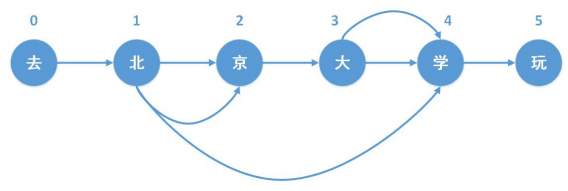

In [10]:
def get_DAG(sentence, FREQ):
    """
    根据句子和前缀词典构建有向无环图 (DAG)。
    """
    DAG = {}
    N = len(sentence)
    for k in range(N):
        tmplist = []
        i = k
        frag = sentence[k]
        # 当frag还是一个有效的前缀时，继续向后扫描
        while i < N and frag in FREQ:
            # 如果frag本身就是一个词（词频>0），则记录其结束位置
            if FREQ[frag] > 0:
                tmplist.append(i)
            i += 1
            frag = sentence[k:i + 1]
        # 如果从k开始找不到任何词（如遇到未登录单字），则它自身成一个词
        if not tmplist:
            tmplist.append(k)
        DAG[k] = tmplist
    return DAG

# --- DAG 示例 ---
sentence_example = "去北京大学玩"
DAG_example = get_DAG(sentence_example, FREQ)
print(f"\n句子 '{sentence_example}' 的DAG: {DAG_example}")
# 解释: DAG[1] = [2, 4] 表示从位置1('北')开始, 可以形成 '北京'(结束于2) 和 '北京大学'(结束于4) 两个词。


句子 '去北京大学玩' 的DAG: {0: [0], 1: [1, 2, 4], 2: [2], 3: [3, 4], 4: [4], 5: [5]}


## 第三部分：动态规划计算最大概率路径

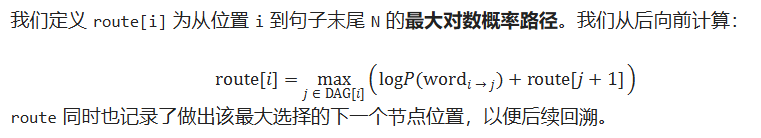

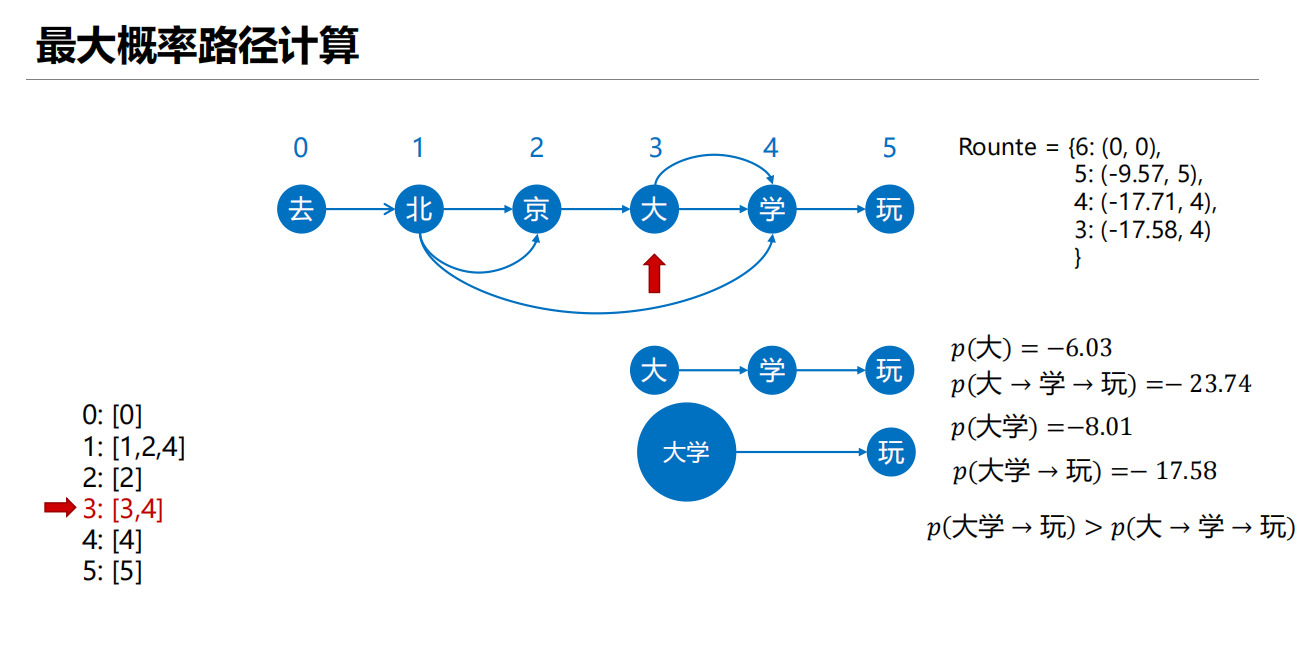

In [11]:
from math import log

def calc_route(sentence, DAG, FREQ, total):
    """
    使用动态规划计算最大概率路径。
    """
    N = len(sentence)
    route = {}
    # 终点N的概率为0 (log(1)=0)，没有下一跳
    route[N] = (0, 0)
    logtotal = log(total)

    # 从后向前递推
    for idx in range(N - 1, -1, -1):
        # route[idx] 将被赋值为 (max_prob, next_node_idx)
        # 我们寻找从idx出发，到哪个后续节点x能获得最大路径概率
        route[idx] = max(
            (
                # 当前词的对数概率 + 后续路径的最大对数概率
                log(FREQ.get(sentence[idx:x + 1]) or 1) - logtotal + route[x + 1][0],
                x # 记录选择的下一个节点位置
            )
            for x in DAG[idx]
        )
    return route

## 第四部分：回溯路径，得到最终分词结果

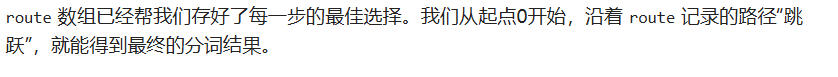

In [13]:
import re
re_eng = re.compile('[a-zA-Z0-9]+', re.U) # 编译正则表达式以提高效率

def final_cut(sentence, DAG, route):
    """
    根据route回溯路径，得到分词结果，并处理连续的英文/数字。
    """
    x = 0
    N = len(sentence)
    result = []
    
    while x < N:
        # 从route中获取从x位置出发的最佳选择的结束点
        y = route[x][1] + 1
        l_word = sentence[x:y]
        result.append(l_word)
        x = y
    
    # 合并连续的英文和数字
    # 这里我们简化处理，直接返回，更复杂的合并逻辑可以在此添加
    # jieba源码中处理更复杂，例如 "word123word"
    return result

# --- 完整流程演示 ---
def cut_DAG(sentence, FREQ, total):
    DAG = get_DAG(sentence, FREQ)
    route = calc_route(sentence, DAG, FREQ, total)
    return final_cut(sentence, DAG, route)

# 测试例子
test_cases = ['项目的研究', '商品和服务', '研究生命起源', '当下雨天地面积水']
for case in test_cases:
    print(f"'{case}'  =>  {cut_DAG(case, FREQ, total)}")

'项目的研究'  =>  ['项目', '的', '研究']
'商品和服务'  =>  ['商品', '和', '服务']
'研究生命起源'  =>  ['研究', '生命', '起源']
'当下雨天地面积水'  =>  ['当', '下雨天', '地面', '积水']


## 作业：封装与评测

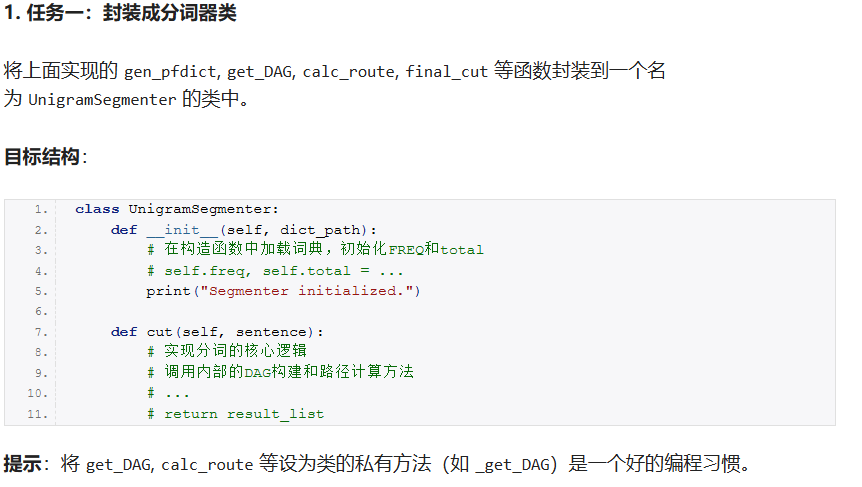

In [14]:
class UnigramSegmenter:
    """
    基于一元语法模型与动态规划的中文分词器
    """
    
    def __init__(self, dict_path=None):
        """
        初始化分词器，加载词典
        :param dict_path: 词典文件路径，如果为None则使用jieba内置词典
        """
        if dict_path is None:
            # 使用 jieba 内置词典
            jieba_dir = os.path.dirname(jieba.__file__)
            dict_path = next(
                (
                    os.path.join(jieba_dir, name)
                    for name in ("jieba_dict.txt", "dict.txt")
                    if os.path.exists(os.path.join(jieba_dir, name))
                ),
                None,
            )
            if dict_path is None:
                raise FileNotFoundError("未在 jieba 安装目录中找到词典文件（jieba_dict.txt 或 dict.txt）")
        
        # 加载词典
        with open(dict_path, encoding="utf-8") as f:
            self.freq, self.total = self._gen_pfdict(f)
        
        print("Segmenter initialized.")
    
    def _gen_pfdict(self, f):
        """
        从词典文件生成前缀词典和总词频数。
        :param f: 打开的词典文件对象。
        :return: (lfreq, ltotal) -> (前缀词典, 总词频)
        """
        lfreq = {}
        ltotal = 0
        for lineno, line in enumerate(f, 1):
            try:
                word, freq = line.strip().split(' ')[:2]
                freq = int(freq)
                lfreq[word] = freq
                ltotal += freq
                # 将词的所有前缀也加入词典，词频设为0，表示它只是一个前缀
                for i in range(len(word)):
                    wfrag = word[:i + 1]
                    if wfrag not in lfreq:
                        lfreq[wfrag] = 0
            except ValueError:
                raise ValueError(f'Invalid dictionary entry in {f.name} at Line {lineno}: {line}')
        f.close()
        return lfreq, ltotal
    
    def _get_DAG(self, sentence):
        """
        根据句子和前缀词典构建有向无环图 (DAG)。
        """
        DAG = {}
        N = len(sentence)
        for k in range(N):
            tmplist = []
            i = k
            frag = sentence[k]
            # 当frag还是一个有效的前缀时，继续向后扫描
            while i < N and frag in self.freq:
                # 如果frag本身就是一个词（词频>0），则记录其结束位置
                if self.freq[frag] > 0:
                    tmplist.append(i)
                i += 1
                frag = sentence[k:i + 1]
            # 如果从k开始找不到任何词（如遇到未登录单字），则它自身成一个词
            if not tmplist:
                tmplist.append(k)
            DAG[k] = tmplist
        return DAG
    
    def _calc_route(self, sentence, DAG):
        """
        使用动态规划计算最大概率路径。
        """
        N = len(sentence)
        route = {}
        # 终点N的概率为0 (log(1)=0)，没有下一跳
        route[N] = (0, 0)
        logtotal = log(self.total)
        
        # 从后向前递推
        for idx in range(N - 1, -1, -1):
            # route[idx] 将被赋值为 (max_prob, next_node_idx)
            # 我们寻找从idx出发，到哪个后续节点x能获得最大路径概率
            route[idx] = max(
                (
                    # 当前词的对数概率 + 后续路径的最大对数概率
                    log(self.freq.get(sentence[idx:x + 1]) or 1) - logtotal + route[x + 1][0],
                    x # 记录选择的下一个节点位置
                )
                for x in DAG[idx]
            )
        return route
    
    def _final_cut(self, sentence, DAG, route):
        """
        根据route回溯路径，得到分词结果，并处理连续的英文/数字。
        """
        x = 0
        N = len(sentence)
        result = []
        
        while x < N:
            # 从route中获取从x位置出发的最佳选择的结束点
            y = route[x][1] + 1
            l_word = sentence[x:y]
            result.append(l_word)
            x = y
        
        return result
    
    def cut(self, sentence):
        """
        分词的核心方法，实现完整的分词流程。
        :param sentence: 待分词的句子
        :return: 分词结果列表
        """
        DAG = self._get_DAG(sentence)
        route = self._calc_route(sentence, DAG)
        return self._final_cut(sentence, DAG, route)


# --- 测试示例 ---
# 创建分词器实例
segmenter = UnigramSegmenter()

# 测试
test_cases = ['项目的研究', '商品和服务', '研究生命起源', '当下雨天地面积水']
print("\n分词结果：")
for case in test_cases:
    result = segmenter.cut(case)
    print(f"'{case}'  =>  {result}")

Segmenter initialized.

分词结果：
'项目的研究'  =>  ['项目', '的', '研究']
'商品和服务'  =>  ['商品', '和', '服务']
'研究生命起源'  =>  ['研究', '生命', '起源']
'当下雨天地面积水'  =>  ['当', '下雨天', '地面', '积水']


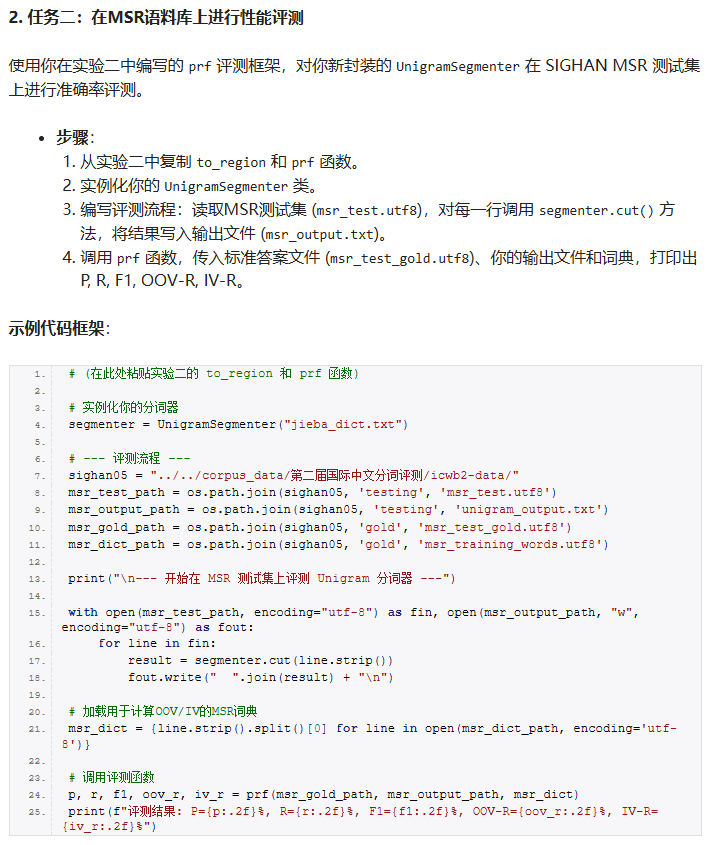

In [ ]:
import os
import re

def to_region(segmentation: str) -> set:
    """将以空格分隔的分词结果字符串转换为词语区间的集合。"""
    region = set()
    start = 0
    for word in re.compile("\\s+").split(segmentation.strip()):
        end = start + len(word)
        region.add((start, end))
        start = end
    return region

def prf(gold: str, pred: str, dic) -> tuple:
    """
    计算P, R, F1, OOV-R, IV-R。
    :param gold: 标准答案文件路径。
    :param pred: 预测结果文件路径。
    :param dic: 词典。
    :return: (P, R, F1, OOV_R, IV_R)
    """
    A_size, B_size, A_cap_B_size = 0, 0, 0  # A:标准答案词数, B:预测结果词数, A&B:正确词数
    OOV, IV = 0, 0  # OOV:标准答案中的未登录词数, IV:标准答案中的登录词数
    OOV_R, IV_R = 0, 0 # OOV_R:正确切分的OOV数, IV_R:正确切分的IV数
    
    with open(gold, encoding="utf-8") as gd, open(pred, encoding="utf-8") as pd:
        for g, p in zip(gd, pd):
            A = to_region(g)
            B = to_region(p)
            A_cap_B = A & B
            
            A_size += len(A)
            B_size += len(B)
            A_cap_B_size += len(A_cap_B)
            
            # 统计OOV和IV的召回情况
            text = re.sub("\\s+", "", g.strip())
            for start, end in A:
                word = text[start:end]
                if word in dic:
                    IV += 1
                    if (start, end) in A_cap_B:
                        IV_R += 1
                else:
                    OOV += 1
                    if (start, end) in A_cap_B:
                        OOV_R += 1
    
    p = A_cap_B_size / B_size * 100 if B_size > 0 else 0
    r = A_cap_B_size / A_size * 100 if A_size > 0 else 0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0
    oov_r = OOV_R / OOV * 100 if OOV > 0 else 0
    iv_r = IV_R / IV * 100 if IV > 0 else 0
    
    return p, r, f1, oov_r, iv_r


# --- 实例化你的分词器 ---
segmenter = UnigramSegmenter()

# --- 评测流程 ---
sighan05 = "./corpus_data/第二届国际中文分词评测/icwb2-data/"
msr_test_path = os.path.join(sighan05, 'testing', 'msr_test.utf8')
msr_output_path = os.path.join(sighan05, 'testing', 'unigram_output.txt')
msr_gold_path = os.path.join(sighan05, 'gold', 'msr_test_gold.utf8')
msr_dict_path = os.path.join(sighan05, 'gold', 'msr_training_words.utf8')

print("\n--- 开始在 MSR 测试集上评测 Unigram 分词器 ---")

with open(msr_test_path, encoding="utf-8") as fin, open(msr_output_path, "w", encoding="utf-8") as fout:
    for line in fin:
        result = segmenter.cut(line.strip())
        fout.write("  ".join(result) + "\n")

# 加载用于计算OOV/IV的MSR词典
msr_dict = {line.strip().split()[0] for line in open(msr_dict_path, encoding='utf-8')}

# 调用评测函数
p, r, f1, oov_r, iv_r = prf(msr_gold_path, msr_output_path, msr_dict)
print(f"评测结果: P={p:.2f}%, R={r:.2f}%, F1={f1:.2f}%, OOV-R={oov_r:.2f}%, IV-R={iv_r:.2f}%")

Segmenter initialized.

--- 开始在 MSR 测试集上评测 Unigram 分词器 ---
评测结果: P=81.89%, R=83.24%, F1=82.56%, OOV-R=33.69%, IV-R=84.59%


In [21]:
with open(msr_test_path, encoding="utf-8") as fin, open(msr_output_path, "w", encoding="utf-8") as fout:
    for line in fin:
        result = segmenter.cut(line.strip())
        print(f"原文: {line.strip()}")
        print(f"分词结果: {result}\n")
        fout.write("  ".join(result) + "\n")

原文: 扬帆远东做与中国合作的先行
分词结果: ['扬帆', '远东', '做', '与', '中国', '合作', '的', '先行']

原文: 希腊的经济结构较特殊。
分词结果: ['希腊', '的', '经济', '结构', '较', '特殊', '。']

原文: 海运业雄踞全球之首，按吨位计占世界总数的１７％。
分词结果: ['海运业', '雄踞', '全球', '之', '首', '，', '按', '吨位', '计', '占', '世界', '总数', '的', '１', '７', '％', '。']

原文: 另外旅游、侨汇也是经济收入的重要组成部分，制造业规模相对较小。
分词结果: ['另外', '旅游', '、', '侨汇', '也', '是', '经济', '收入', '的', '重要', '组成部分', '，', '制造业', '规模', '相对', '较', '小', '。']

原文: 多年来，中希贸易始终处于较低的水平，希腊几乎没有在中国投资。
分词结果: ['多年', '来', '，', '中', '希', '贸易', '始终', '处于', '较', '低', '的', '水平', '，', '希腊', '几乎', '没有', '在', '中国', '投资', '。']

原文: 十几年来，改革开放的中国经济高速发展，远东在崛起。
分词结果: ['十几年来', '，', '改革开放', '的', '中国', '经济', '高速', '发展', '，', '远东', '在', '崛起', '。']

原文: 瓦西里斯的船只中有４０％驶向远东，每个月几乎都有两三条船停靠中国港口。
分词结果: ['瓦西里', '斯', '的', '船只', '中', '有', '４', '０', '％', '驶向', '远东', '，', '每个', '月', '几乎', '都', '有', '两三条', '船', '停靠', '中国', '港口', '。']

原文: 他感受到了中国经济发展的大潮。
分词结果: ['他', '感受', '到', '了', '中国', '经济', '发展', '的', '大潮', '。']

原文: 他要与中国人合作。
分词结果: ['他', '要', '与', '中国', '人', '合作', '。']

原文: 他